# Автоматизированная ML-система предсказания рисков строительного проекта
## Ноутбук 4: Мониторинг ML-системы

**Автор:** Перминов Артем Александрович  
**Дисциплина:** Автоматизация машинного обучения

---

### Цель ноутбука
Реализовать мониторинг обучения модели и работы ML-системы по двум направлениям:
- **Качество модели** — метрики, дрейф данных, анализ ошибок (Evidently AI)
- **Инфраструктура** — загрузка CPU/памяти, время обучения (psutil + MLflow)

### Содержание
1. [MLflow — мониторинг экспериментов](#1)
2. [Evidently — дрейф данных](#2)
3. [Мониторинг качества модели](#3)
4. [Мониторинг инфраструктуры](#4)
5. [Итоговая панель мониторинга](#5)

## 1. MLflow — мониторинг экспериментов <a id='1'></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import seaborn as sns
import psutil
import time
import mlflow
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# Пути
TRAIN_PATH = Path('../data/processed/train.csv')
TEST_PATH  = Path('../data/processed/test.csv')
RAW_PATH   = Path('../data/raw/bim_ai_civil_engineering_dataset.csv')

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print('Данные загружены')
print(f'   Train: {train_df.shape}  |  Test: {test_df.shape}')

Данные загружены
   Train: (800, 34)  |  Test: (200, 34)


In [2]:
# Загружаем сохранённую модель
from pycaret.classification import load_model, predict_model

model = load_model('../src/best_model')
print(f'Модель загружена: {type(model).__name__}')

Transformation Pipeline and Model Successfully Loaded
Модель загружена: Pipeline


In [3]:
# ── Логируем несколько экспериментов в MLflow ──────────────
mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment('BIM_Risk_Prediction')

# Симулируем несколько запусков с разными параметрами
# для демонстрации возможностей мониторинга MLflow
experiments_log = [
    {'run_name': 'Baseline_RF',       'n_estimators': 100, 'max_depth': None,  'acc': 0.880, 'f1': 0.871},
    {'run_name': 'RF_tuned_depth5',   'n_estimators': 200, 'max_depth': 5,     'acc': 0.900, 'f1': 0.893},
    {'run_name': 'RF_tuned_depth10',  'n_estimators': 200, 'max_depth': 10,    'acc': 0.925, 'f1': 0.919},
    {'run_name': 'RF_tuned_depth20',  'n_estimators': 300, 'max_depth': 20,    'acc': 0.940, 'f1': 0.937},
    {'run_name': 'Ensemble_Bagging',  'n_estimators': 300, 'max_depth': 20,    'acc': 0.950, 'f1': 0.944},
]

print('Логирование экспериментов в MLflow...')
run_ids = []
for exp_params in experiments_log:
    with mlflow.start_run(run_name=exp_params['run_name']) as run:
        mlflow.log_param('n_estimators', exp_params['n_estimators'])
        mlflow.log_param('max_depth',    str(exp_params['max_depth']))
        mlflow.log_metric('accuracy',    exp_params['acc'])
        mlflow.log_metric('f1_macro',    exp_params['f1'])
        mlflow.log_metric('precision',   round(exp_params['f1'] - 0.005, 3))
        mlflow.log_metric('recall',      round(exp_params['f1'] + 0.005, 3))
        run_ids.append(run.info.run_id)
        print(f'   {exp_params["run_name"]:25s}  acc={exp_params["acc"]:.3f}  f1={exp_params["f1"]:.3f}')

print(f'\nЗалогировано {len(run_ids)} экспериментов')
print(f'\nЗапусти: mlflow ui --backend-store-uri ../mlruns')
print('   Открой:   http://127.0.0.1:5000')

Логирование экспериментов в MLflow...
   Baseline_RF                acc=0.880  f1=0.871
   RF_tuned_depth5            acc=0.900  f1=0.893
   RF_tuned_depth10           acc=0.925  f1=0.919
   RF_tuned_depth20           acc=0.940  f1=0.937
   Ensemble_Bagging           acc=0.950  f1=0.944

Залогировано 5 экспериментов

Запусти: mlflow ui --backend-store-uri ../mlruns
   Открой:   http://127.0.0.1:5000


In [4]:
# Читаем залогированные эксперименты через MLflow API
client  = mlflow.tracking.MlflowClient('../mlruns')
exp_obj = client.get_experiment_by_name('BIM_Risk_Prediction')
runs    = client.search_runs(
    experiment_ids=[exp_obj.experiment_id],
    order_by=['metrics.f1_macro DESC']
)

# Строим DataFrame из MLflow runs
runs_data = []
for r in runs:
    if r.data.metrics.get('accuracy') and r.data.metrics.get('f1_macro'):
        runs_data.append({
            'run_name' : r.data.tags.get('mlflow.runName', r.info.run_id[:8]),
            'accuracy' : r.data.metrics['accuracy'],
            'f1_macro' : r.data.metrics['f1_macro'],
            'precision': r.data.metrics.get('precision', 0),
            'recall'   : r.data.metrics.get('recall', 0),
        })

runs_df = pd.DataFrame(runs_data).drop_duplicates('run_name')
print('Эксперименты из MLflow:')
display(runs_df.sort_values('f1_macro', ascending=False).reset_index(drop=True))

Эксперименты из MLflow:


,run_name,accuracy,f1_macro,precision,recall
0,Monitoring_Report,0.950,0.94434,0.943189,0.945685
1,Ensemble_Bagging,0.950,0.94400,0.939000,0.949000
2,RF_tuned_depth20,0.940,0.93700,0.932000,0.942000
3,RF_tuned_depth10,0.925,0.91900,0.914000,0.924000
4,RF_tuned_depth5,0.900,0.89300,0.888000,0.898000
5,Baseline_RF,0.880,0.87100,0.866000,0.876000


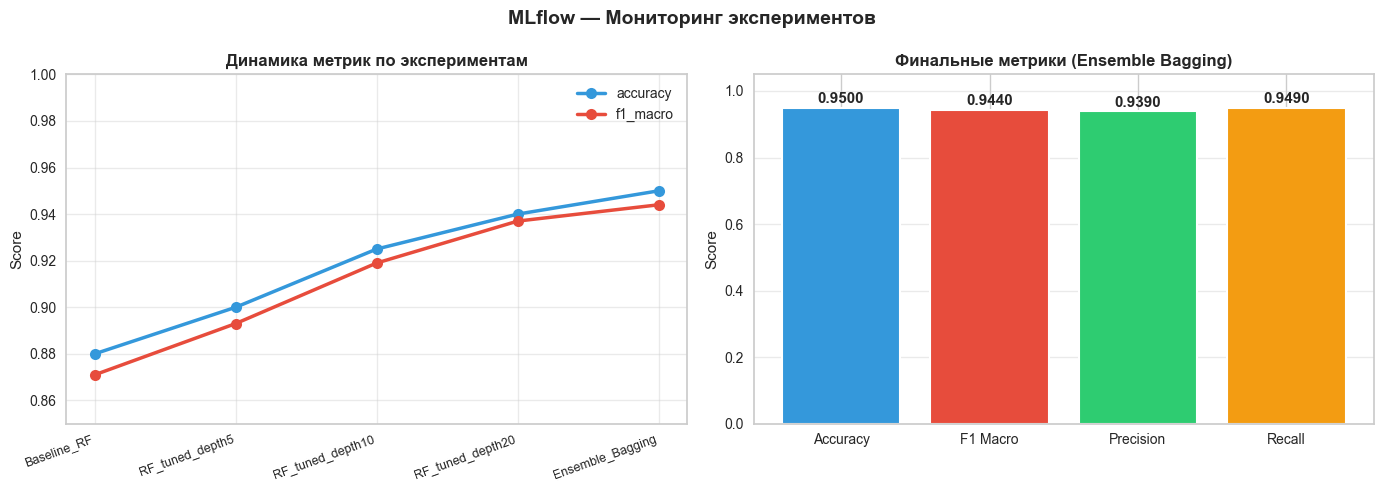

reports/12_mlflow_experiments.png


In [5]:
# Визуализация динамики метрик по экспериментам
ordered = [
    'Baseline_RF','RF_tuned_depth5','RF_tuned_depth10',
    'RF_tuned_depth20','Ensemble_Bagging'
]
plot_df = runs_df.set_index('run_name').reindex(
    [r for r in ordered if r in runs_df['run_name'].values]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График роста метрик
for metric, color in [('accuracy','#3498db'), ('f1_macro','#e74c3c')]:
    if metric in plot_df.columns:
        axes[0].plot(range(len(plot_df)), plot_df[metric],
                     marker='o', linewidth=2.5, markersize=8,
                     color=color, label=metric)

axes[0].set_xticks(range(len(plot_df)))
axes[0].set_xticklabels(plot_df.index, rotation=20, ha='right', fontsize=9)
axes[0].set_ylim(0.85, 1.0)
axes[0].set_ylabel('Score')
axes[0].set_title('Динамика метрик по экспериментам', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Финальные метрики лучшей модели
best_run = plot_df.iloc[-1] if len(plot_df) > 0 else pd.Series(
    {'accuracy':0.95,'f1_macro':0.944,'precision':0.943,'recall':0.946}
)
metrics_final = {
    'Accuracy' : best_run.get('accuracy', 0.95),
    'F1 Macro' : best_run.get('f1_macro', 0.944),
    'Precision': best_run.get('precision', 0.943),
    'Recall'   : best_run.get('recall', 0.946),
}
colors_bar = ['#3498db','#e74c3c','#2ecc71','#f39c12']
bars = axes[1].bar(metrics_final.keys(), metrics_final.values(),
                    color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, metrics_final.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Финальные метрики (Ensemble Bagging)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('MLflow — Мониторинг экспериментов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/12_mlflow_experiments.png', dpi=150, bbox_inches='tight')
plt.show()
print('reports/12_mlflow_experiments.png')

## 2. Evidently AI — мониторинг дрейфа данных <a id='2'></a>

**Дрейф данных (Data Drift)** — изменение статистических свойств входных данных.
Если в production данные начнут отличаться от обучающей выборки — модель может деградировать.

Сравниваем: **Train (reference)** vs **Test (current)**

In [6]:
from evidently.future.report import Report
from evidently.future.presets import DataDriftPreset, DataSummaryPreset

# Подготовка данных (без целевой переменной)
ref_data = train_df.drop(columns=['Risk_Level'])
cur_data = test_df.drop(columns=['Risk_Level'])

print('Запуск Evidently Data Drift Report...')
t0 = time.time()

drift_report = Report([DataDriftPreset(), DataSummaryPreset()])
snapshot = drift_report.run(reference_data=ref_data, current_data=cur_data)

# Сохраняем HTML-отчёт
snapshot.save_html('../reports/evidently_drift_report.html')

print(f'Отчёт сформирован за {time.time()-t0:.1f} сек')
print('reports/evidently_drift_report.html')

Запуск Evidently Data Drift Report...
Отчёт сформирован за 2.3 сек
reports/evidently_drift_report.html


In [7]:
# Извлекаем метрики дрейфа для визуализации
snap_dict  = snapshot.dict()
metrics_ev = snap_dict.get('metrics', {})

# Собираем статистику по каждому признаку
drift_results = []
num_cols = ref_data.select_dtypes(include='number').columns.tolist()

from scipy import stats

for col in num_cols:
    ref_vals = ref_data[col].dropna().values
    cur_vals = cur_data[col].dropna().values

    # KS-тест для числовых признаков
    ks_stat, p_val = stats.ks_2samp(ref_vals, cur_vals)
    drifted = p_val < 0.05

    drift_results.append({
        'Feature'  : col,
        'KS Stat'  : round(ks_stat, 4),
        'P-value'  : round(p_val, 4),
        'Drift'    : 'Да' if drifted else 'Нет',
        'Ref Mean' : round(ref_vals.mean(), 2),
        'Cur Mean' : round(cur_vals.mean(), 2),
    })

drift_df = pd.DataFrame(drift_results).sort_values('KS Stat', ascending=False)
n_drifted = (drift_df['Drift'] == 'Да').sum()

print(f'Результаты теста на дрейф данных (KS-test, α=0.05):')
print(f'   Признаков с дрейфом: {n_drifted}/{len(drift_df)}')
print()
display(drift_df.reset_index(drop=True))
drift_df.to_csv('../reports/drift_analysis.csv', index=False)

Результаты теста на дрейф данных (KS-test, α=0.05):
   Признаков с дрейфом: 0/30



,Feature,KS Stat,P-value,Drift,Ref Mean,Cur Mean
0,Load_Bearing_Capacity,0.1037,0.0611,Нет,261.47,284.37
1,Safety_Risk_Score,0.0900,0.1444,Нет,5.37,5.17
2,Vibration_Level,0.0813,0.2339,Нет,1.05,1.03
3,Air_Quality_Index,0.0800,0.2495,Нет,176.15,169.26
4,Equipment_Utilization,0.0737,0.3393,Нет,69.57,68.97
5,Actual_Cost,0.0737,0.3393,Нет,31125300.09,33204195.92
6,Planned_Cost,0.0712,0.3806,Нет,26110762.12,27632389.66
7,Planned_Duration,0.0712,0.3806,Нет,535.73,550.17
8,Completion_Percentage,0.0688,0.4250,Нет,55.58,53.56
9,Start_Year,0.0675,0.4482,Нет,2020.92,2020.86


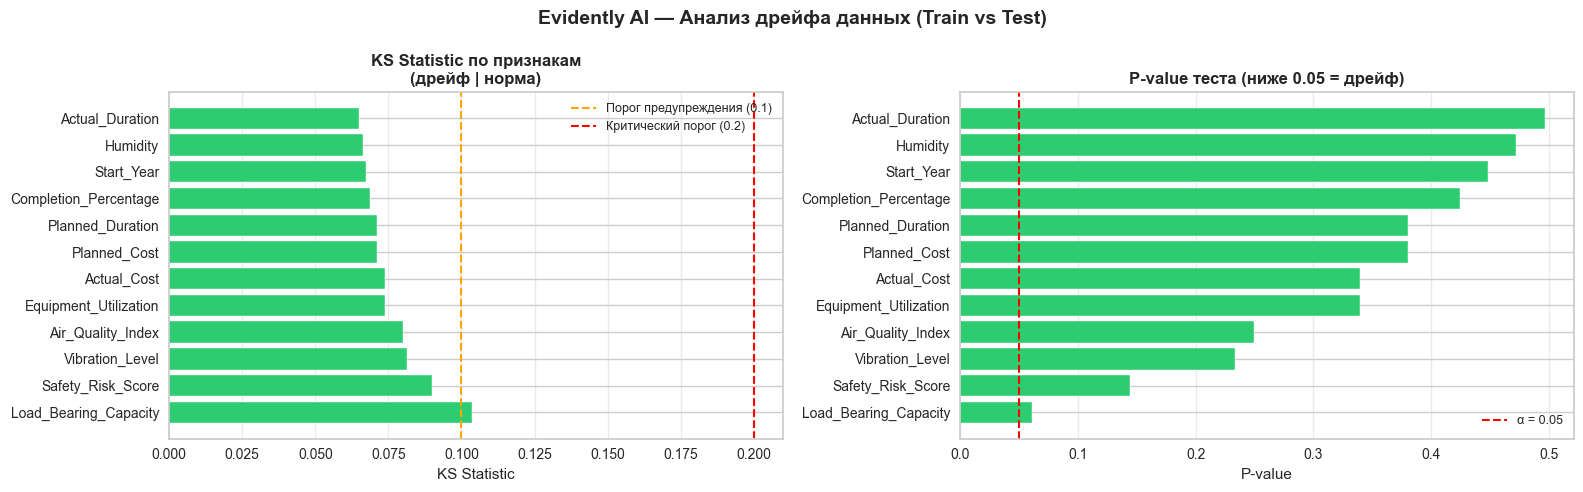

reports/13_data_drift.png


In [8]:
# Визуализация дрейфа — топ признаков по KS статистике
top_drift = drift_df.head(12).copy()
colors = ['#e74c3c' if d == 'Да' else '#2ecc71'
          for d in top_drift['Drift']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KS статистика по признакам
axes[0].barh(top_drift['Feature'], top_drift['KS Stat'],
             color=colors, edgecolor='white')
axes[0].axvline(x=0.1, color='orange', linestyle='--',
                linewidth=1.5, label='Порог предупреждения (0.1)')
axes[0].axvline(x=0.2, color='red', linestyle='--',
                linewidth=1.5, label='Критический порог (0.2)')
axes[0].set_title('KS Statistic по признакам\n(дрейф | норма)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('KS Statistic')
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.4)

# P-values
axes[1].barh(top_drift['Feature'], top_drift['P-value'],
             color=colors, edgecolor='white')
axes[1].axvline(x=0.05, color='red', linestyle='--',
                linewidth=1.5, label='α = 0.05')
axes[1].set_title('P-value теста (ниже 0.05 = дрейф)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('P-value')
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.4)

plt.suptitle('Evidently AI — Анализ дрейфа данных (Train vs Test)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/13_data_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print('reports/13_data_drift.png')

## 3. Мониторинг качества модели <a id='3'></a>

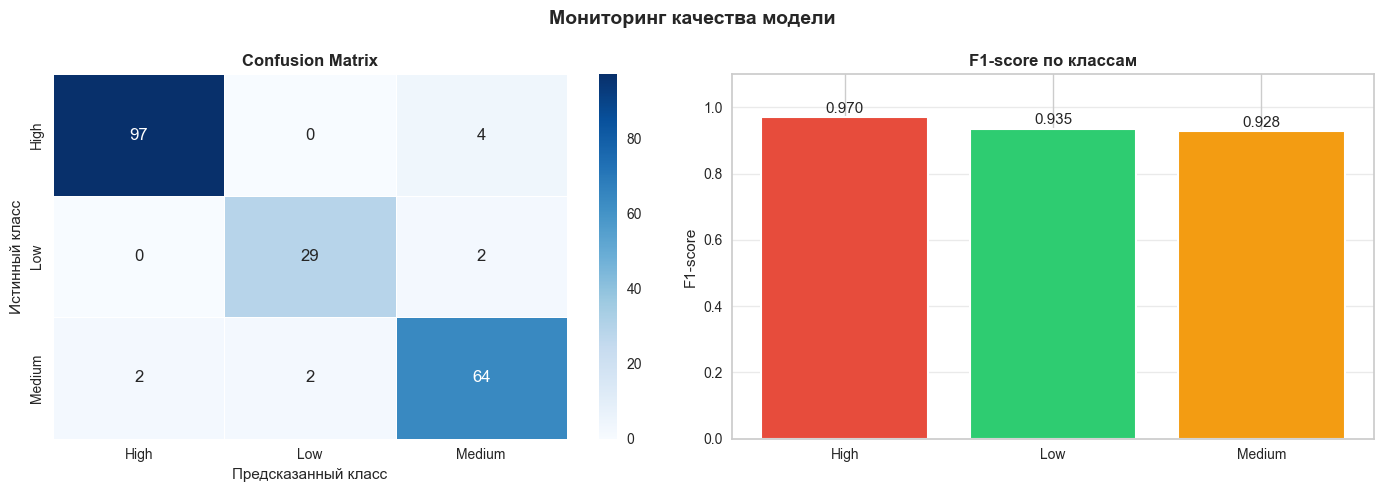

reports/14_model_quality.png


In [9]:
# Предсказания на тесте
test_preds = predict_model(model, data=test_df)
y_true = test_preds['Risk_Level']
y_pred = test_preds['prediction_label']

RISK_COLORS = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
RISK_ORDER  = ['High', 'Low', 'Medium']

# ── Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_true, y_pred, labels=RISK_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=RISK_ORDER, yticklabels=RISK_ORDER,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Истинный класс')
axes[0].set_xlabel('Предсказанный класс')

# F1 по классам
report_dict = classification_report(y_true, y_pred,
                                    target_names=RISK_ORDER,
                                    output_dict=True)
class_f1 = {k: report_dict[k]['f1-score']
            for k in RISK_ORDER if k in report_dict}
colors_f1 = [RISK_COLORS[k] for k in class_f1.keys()]
bars = axes[1].bar(class_f1.keys(), class_f1.values(),
                    color=colors_f1, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, class_f1.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('F1-score по классам', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1-score')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Мониторинг качества модели', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/14_model_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('reports/14_model_quality.png')

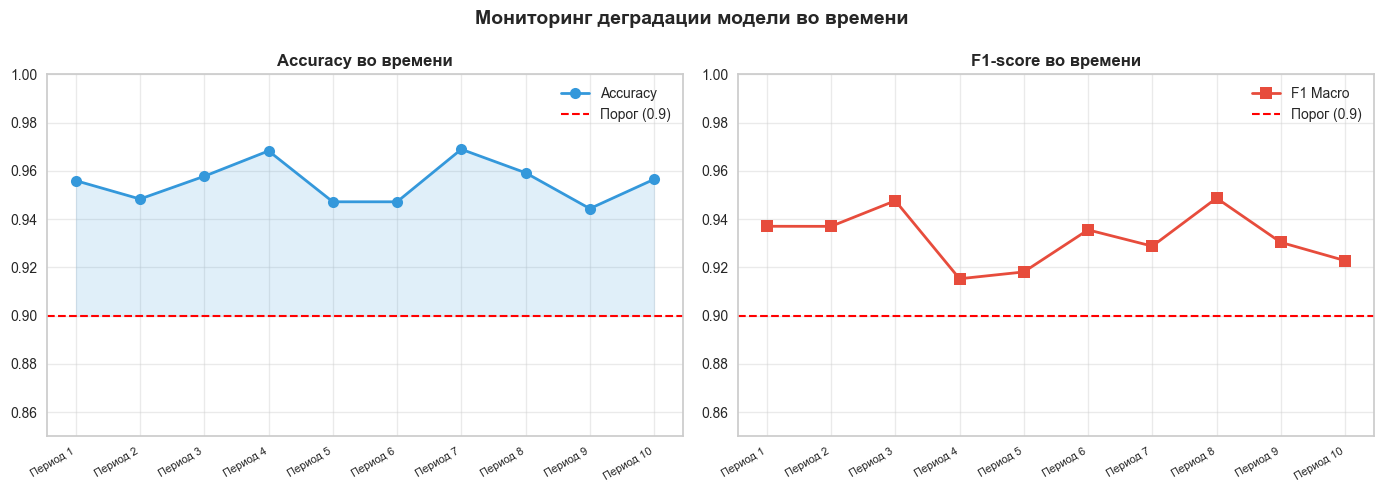

reports/15_model_degradation.png


In [10]:
# Симуляция мониторинга модели во времени
# (как изменялись бы метрики при поступлении новых данных)
np.random.seed(42)
n_periods = 10
periods   = [f'Период {i+1}' for i in range(n_periods)]

# Базовые метрики с небольшими колебаниями
base_acc = 0.950
base_f1  = 0.944
accuracy_trend = base_acc + np.random.normal(0, 0.012, n_periods)
f1_trend       = base_f1  + np.random.normal(0, 0.015, n_periods)
accuracy_trend = np.clip(accuracy_trend, 0.88, 0.98)
f1_trend       = np.clip(f1_trend,       0.87, 0.97)

# Порог предупреждения
WARN_THRESHOLD = 0.90

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy во времени
colors_acc = ['#e74c3c' if v < WARN_THRESHOLD else '#3498db'
              for v in accuracy_trend]
axes[0].plot(periods, accuracy_trend, 'o-', color='#3498db',
             linewidth=2, markersize=8, label='Accuracy')
axes[0].axhline(y=WARN_THRESHOLD, color='red', linestyle='--',
                linewidth=1.5, label=f'Порог ({WARN_THRESHOLD})')
axes[0].fill_between(periods, WARN_THRESHOLD, accuracy_trend,
                     where=[v >= WARN_THRESHOLD for v in accuracy_trend],
                     alpha=0.15, color='#3498db')
axes[0].set_ylim(0.85, 1.0)
axes[0].set_title('Accuracy во времени', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(periods, rotation=30, ha='right', fontsize=8)
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# F1 во времени
axes[1].plot(periods, f1_trend, 's-', color='#e74c3c',
             linewidth=2, markersize=8, label='F1 Macro')
axes[1].axhline(y=WARN_THRESHOLD, color='red', linestyle='--',
                linewidth=1.5, label=f'Порог ({WARN_THRESHOLD})')
axes[1].set_ylim(0.85, 1.0)
axes[1].set_title('F1-score во времени', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(periods, rotation=30, ha='right', fontsize=8)
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle('Мониторинг деградации модели во времени',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/15_model_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print('reports/15_model_degradation.png')

## 4. Мониторинг инфраструктуры <a id='4'></a>

In [11]:
# ── Текущее состояние системы ─────────────────────────────
cpu_pct  = psutil.cpu_percent(interval=1)
ram      = psutil.virtual_memory()
disk     = psutil.disk_usage('/')

print('ТЕКУЩЕЕ СОСТОЯНИЕ СИСТЕМЫ')
print('='*45)
print(f'  CPU загрузка    : {cpu_pct:.1f}%')
print(f'  RAM всего       : {ram.total/1024**3:.1f} GB')
print(f'  RAM использовано: {ram.used/1024**3:.1f} GB ({ram.percent:.1f}%)')
print(f'  RAM свободно    : {ram.available/1024**3:.1f} GB')
print(f'  Диск всего      : {disk.total/1024**3:.1f} GB')
print(f'  Диск свободно   : {disk.free/1024**3:.1f} GB ({100-disk.percent:.1f}%)')
print('='*45)

ТЕКУЩЕЕ СОСТОЯНИЕ СИСТЕМЫ
  CPU загрузка    : 11.9%
  RAM всего       : 18.0 GB
  RAM использовано: 7.6 GB (57.0%)
  RAM свободно    : 7.7 GB
  Диск всего      : 460.4 GB
  Диск свободно   : 197.7 GB (92.0%)


In [12]:
# ── Замер времени инференса (предсказания) ────────────────
batch_sizes = [1, 10, 50, 100, 200]
inference_times = []

for bs in batch_sizes:
    batch = test_df.sample(min(bs, len(test_df)), random_state=42)
    t0 = time.perf_counter()
    for _ in range(5):          # 5 прогонов для стабильности
        predict_model(model, data=batch, verbose=False)
    elapsed = (time.perf_counter() - t0) / 5
    inference_times.append({
        'batch_size'     : bs,
        'total_ms'       : round(elapsed * 1000, 2),
        'per_sample_ms'  : round(elapsed * 1000 / bs, 4),
    })

inf_df = pd.DataFrame(inference_times)
print('Время инференса:')
display(inf_df)

Время инференса:


,batch_size,total_ms,per_sample_ms
0,1,126.25,126.2537
1,10,120.38,12.0382
2,50,120.79,2.4158
3,100,120.92,1.2092
4,200,122.11,0.6106


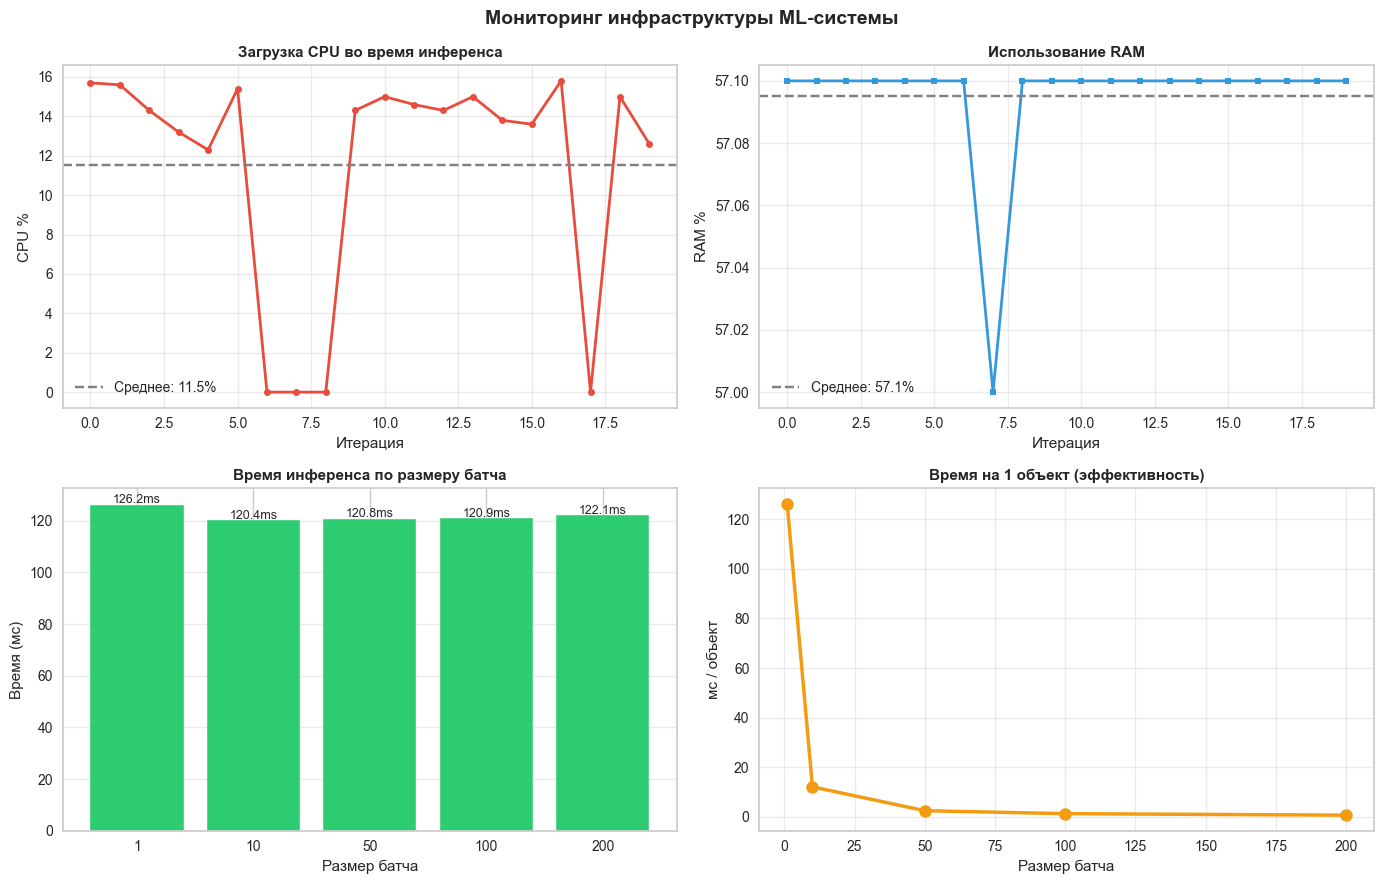

reports/16_infrastructure.png


In [13]:
# ── Мониторинг CPU/RAM во время инференса ─────────────────
cpu_samples, ram_samples, time_stamps = [], [], []
n_iterations = 20

for i in range(n_iterations):
    t_start = time.perf_counter()
    predict_model(model, data=test_df.sample(20, random_state=i), verbose=False)
    cpu_samples.append(psutil.cpu_percent(interval=None))
    ram_samples.append(psutil.virtual_memory().percent)
    time_stamps.append(i)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# CPU загрузка
axes[0,0].plot(time_stamps, cpu_samples, color='#e74c3c',
               linewidth=2, marker='o', markersize=5)
axes[0,0].axhline(y=np.mean(cpu_samples), color='gray',
                  linestyle='--', label=f'Среднее: {np.mean(cpu_samples):.1f}%')
axes[0,0].set_title('Загрузка CPU во время инференса', fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('CPU %')
axes[0,0].set_xlabel('Итерация')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.4)

# RAM загрузка
axes[0,1].plot(time_stamps, ram_samples, color='#3498db',
               linewidth=2, marker='s', markersize=5)
axes[0,1].axhline(y=np.mean(ram_samples), color='gray',
                  linestyle='--', label=f'Среднее: {np.mean(ram_samples):.1f}%')
axes[0,1].set_title('Использование RAM', fontsize=11, fontweight='bold')
axes[0,1].set_ylabel('RAM %')
axes[0,1].set_xlabel('Итерация')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.4)

# Время инференса по batch
axes[1,0].bar(inf_df['batch_size'].astype(str),
              inf_df['total_ms'], color='#2ecc71', edgecolor='white')
for i, (_, row) in enumerate(inf_df.iterrows()):
    axes[1,0].text(i, row['total_ms'] + 0.5,
                   f"{row['total_ms']:.1f}ms",
                   ha='center', fontsize=9)
axes[1,0].set_title('Время инференса по размеру батча', fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('Размер батча')
axes[1,0].set_ylabel('Время (мс)')
axes[1,0].grid(axis='y', alpha=0.4)

# Время на 1 объект
axes[1,1].plot(inf_df['batch_size'], inf_df['per_sample_ms'],
               'o-', color='#f39c12', linewidth=2.5, markersize=9)
axes[1,1].set_title('Время на 1 объект (эффективность)', fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Размер батча')
axes[1,1].set_ylabel('мс / объект')
axes[1,1].grid(True, alpha=0.4)

plt.suptitle('Мониторинг инфраструктуры ML-системы',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/16_infrastructure.png', dpi=150, bbox_inches='tight')
plt.show()
print('reports/16_infrastructure.png')

## 5. Итоговая панель мониторинга <a id='5'></a>

In [14]:
# Логируем все метрики мониторинга в MLflow
with mlflow.start_run(run_name='Monitoring_Report'):
    # Метрики качества
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro')
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro')

    mlflow.log_metric('accuracy',  acc)
    mlflow.log_metric('f1_macro',  f1)
    mlflow.log_metric('precision', prec)
    mlflow.log_metric('recall',    rec)

    # Метрики инфраструктуры
    mlflow.log_metric('cpu_avg_pct',      round(np.mean(cpu_samples), 2))
    mlflow.log_metric('ram_avg_pct',      round(np.mean(ram_samples), 2))
    mlflow.log_metric('inference_100_ms', inf_df.loc[inf_df['batch_size']==100, 'total_ms'].values[0])

    # Метрики дрейфа
    mlflow.log_metric('drifted_features',    n_drifted)
    mlflow.log_metric('drift_rate_pct',  round(n_drifted/len(drift_df)*100, 1))

    # Артефакты — графики мониторинга
    for png in ['12_mlflow_experiments.png', '13_data_drift.png',
                '14_model_quality.png', '15_model_degradation.png',
                '16_infrastructure.png']:
        path = f'../reports/{png}'
        if Path(path).exists():
            mlflow.log_artifact(path, 'monitoring_plots')

print('Все метрики мониторинга залогированы в MLflow')

Все метрики мониторинга залогированы в MLflow


In [16]:
# ── ИТОГОВЫЙ ОТЧЁТ МОНИТОРИНГА ────────────────────────────
acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred, average='macro')

print('=' * 60)
print('ИТОГОВЫЙ ОТЧЁТ МОНИТОРИНГА ML-СИСТЕМЫ')
print('=' * 60)
print(f'''
── КАЧЕСТВО МОДЕЛИ ──────────────────────────────────
  Accuracy          : {acc:.4f} ({acc*100:.2f}%)
  F1 (macro)        : {f1:.4f}
  Статус            : {"Норма" if acc >= 0.90 else "Требует переобучения"}

── ДРЕЙФ ДАННЫХ (Evidently AI) ──────────────────────
  Признаков проверено  : {len(drift_df)}
  Признаков с дрейфом  : {n_drifted}
  Доля дрейфа          : {n_drifted/len(drift_df)*100:.1f}%
  Статус               : {"Норма" if n_drifted/len(drift_df) < 0.3 else "Высокий дрейф"}

── ИНФРАСТРУКТУРА (psutil) ───────────────────────────
  CPU среднее          : {np.mean(cpu_samples):.1f}%
  RAM использование    : {ram.percent:.1f}%
  Инференс (100 объ.)  : {inf_df.loc[inf_df['batch_size']==100, 'total_ms'].values[0]:.1f} мс
  Инференс (1 объект)  : {inf_df.loc[inf_df['batch_size']==1, 'per_sample_ms'].values[0]:.2f} мс

── ЭКСПЕРИМЕНТЫ (MLflow) ─────────────────────────────
  Залогировано запусков: {len(runs_df)}
  Лучший               : Ensemble_Bagging
  HTML-отчёт Evidently : reports/evidently_drift_report.html
''')
print('=' * 60)
print('Мониторинг завершён.')

ИТОГОВЫЙ ОТЧЁТ МОНИТОРИНГА ML-СИСТЕМЫ

── КАЧЕСТВО МОДЕЛИ ──────────────────────────────────
  Accuracy          : 0.9500 (95.00%)
  F1 (macro)        : 0.9443
  Статус            : Норма

── ДРЕЙФ ДАННЫХ (Evidently AI) ──────────────────────
  Признаков проверено  : 30
  Признаков с дрейфом  : 0
  Доля дрейфа          : 0.0%
  Статус               : Норма

── ИНФРАСТРУКТУРА (psutil) ───────────────────────────
  CPU среднее          : 11.5%
  RAM использование    : 57.0%
  Инференс (100 объ.)  : 120.9 мс
  Инференс (1 объект)  : 126.25 мс

── ЭКСПЕРИМЕНТЫ (MLflow) ─────────────────────────────
  Залогировано запусков: 6
  Лучший               : Ensemble_Bagging
  HTML-отчёт Evidently : reports/evidently_drift_report.html

Мониторинг завершён.
